<a href="https://colab.research.google.com/github/adrygarcia04/Math-BSc/blob/main/PE/Simulaci%C3%B3n_MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIMULACIÓN DE CADENAS DE MARKOV**

**Autor:** Adrián García Barragán\
**Fecha:** 23/05/2026

## **1. Introducción**
Esta Jupyter Notebook en Google Colab se desarrolla en el seno de la asignatura «Procesos Estocásticos», una asignatura optativa del Grado en Matemáticas por la Universidad de Granada. El planteamiento para el curso 2025/2026 de esta asignatura, tiene como uno de sus objetivos transversales desarrollar competencias complementarias a las adquiridas en dicha titulación tales como el lenguaje de programación Python y algunas de sus librerías más útiles para la ciencia de datos y modelización (por ejemplo: NumPy, Matplotlib, ...).

Concretamente, este archivo es un ejercicio entregable que consiste en realizar simulaciones sobre cadenas de Markov (MC's), que son procesos estocásticos indexados en $\mathbb{N}$ cuyo espacio de estados es discreto y verifican la propiedad de Markov.

In [84]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

---

## **2. Simular la trayectoria de una MC**

Defino una función que nos permita generar trayectorias de una MC dada. Primero la definiremos de la manera más sencilla, usando dos bucles `for`. Después mostraré que se puede eliminar uno de los bucles para hacerlo más eficiente.

Para una MC con $m$ estados, nos hemos referido a ellos como $\{1,2,\dots,m\}$. Y queremos que esta función que simula trayectorias nos devuelva efectivamente esos posibles estados. Hay al menos dos formas de hacer esto:

1. Hacer toda la implementación usando dicha nomenclatura: $\{1,2,\dots,m\}$.

2. Hacer la implementación usando la siguiente nomenclatura: $\{0,1,\dots,m-1\}$. Es decir, al estado $i$-ésimo pasamos a llamarlo «estado $i-1$» durante la implementación. Y, al final de la función, cuando vayamos a devolver los valores, sumamos $+1$ para que el usuario reciba la verdadera nomenclatura.

La opción 1 parece más sencilla desde el punto de vista lógico. Pero, a la hora de hacer la implementación, puesto que Numpy empieza la indexación en 0 (es decir, el primer elemento de un array de numpy está en la posición 0), el código queda mucho más sencillo y limpio si usamos la opción 2.

In [85]:
def simular_trayectorias(P,pi_sup_1,n_samples,n_steps):
  """
  Simular trayectorias de una MC.

  INPUT:
    P (numpy.ndarry (m,m)): Matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): Distribución inicial de la MC.
    n_samples (int): Número de trayectorias a simular.
    n_steps (int): Número de pasos de la simulación.

  OUTPUT:
    trayectorias (numpy.ndarry (n_samples, n_steps)): Trayectorias simuladas.
  """

  m=np.shape(P)[1] #Por comodidad creo la variable m para guardar el número de estados.
  trayectorias=np.zeros((n_samples,n_steps),dtype=int)
  trayectorias[:,0]=np.random.choice(m,n_samples,True,p=pi_sup_1) #Simulo el estado inicial para cada una de las n_samples trayectorias y lo guardo en la primera columna del array trayectorias.

  #Itero sobre n_samples y n_steps para rellenar todo el array "trayectorias".
  for step in range(1, n_steps):
    for sample in range(n_samples):
      trayectorias[sample,step]=np.random.choice(m,1,True,p=P[trayectorias[sample,step-1],:])

  return trayectorias+1

A continuación se presenta una versión más eficiente de esta función, eliminando uno de los bucles `for` (concretamente, el que recorre `n_samples`). El otro bucle, el que recorre `n_steps`, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo. Pero la dimensión sobre `n_samples` sí que es conceptualmente paralelizable.

In [86]:
# COMPLETAR: usando solo un bucle for, sobre n_steps

def simular_trayectorias_effic(P,pi_sup_1,n_samples,n_steps):
  """
  Simular trayectorias de una MC.

  INPUT:
    P (numpy.ndarry (m,m)): Matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): Distribución inicial de la MC.
    n_samples (int): Número de trayectorias a simular.
    n_steps (int): Número de pasos de la simulación.

  OUTPUT:
    trayectorias (numpy.ndarry (n_samples, n_steps)): Trayectorias simuladas.
  """

  m=np.shape(P)[1] #Por comodidad creo la variable m para guardar el número de estados.
  trayectorias=np.zeros((n_samples,n_steps),dtype=int)
  trayectorias[:,0]=np.random.choice(range(m),n_samples,True,p=pi_sup_1) #Simulo el estado inicial para cada una de las n_samples trayectorias y lo guardo en la primera columna del array trayectorias.
  P_cum=np.cumsum(P, axis=1) #Defino esta variable aquí porque lo voy a utilizar en el bucle.

  #Itero sobre n_steps, haciendo uso de np.argmax() y np.random.rand utiliza para generar conjuntamente todas las trayectorias (con un solo bucle for).
  for step in range(1,n_steps):
    aux=np.random.rand(n_samples)
    trayectorias[:,step]=np.argmax(P_cum[trayectorias[:,step-1],:]>=aux[:,None],axis=1)

  return trayectorias+1

Una vez implementadas ambas opciones, utilizo las siguientes celdas para evaluar su eficiencia.

El comando `%%timeit` al principio de una celda hace que se ejecute varias veces y se devuelva un resumen de tiempo de ejecución (media y desviación típica sobre diferentes pruebas).

In [87]:
%%timeit
# Celda para la versión menos eficiente
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1=np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples=1000
n_steps=50
trayectorias=simular_trayectorias(P,pi_sup_1,n_samples,n_steps)

/tmp/ipykernel_9291/3267998693.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trayectorias[sample,step]=np.random.choice(m,1,True,p=P[trayectorias[sample,step-1],:])


1.62 s ± 256 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [88]:
%%timeit
# Celda para la versión más eficiente
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1=np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples=1000
n_steps=50
trayectorias=simular_trayectorias_effic(P,pi_sup_1,n_samples,n_steps)

3.47 ms ± 79.3 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Por último en esta sección, utilizo la función eficiente para generar $6$ trayectorias de $50$ pasos, y las visualizo de forma similar a la diapositiva 24. Para esta tarea recurro a `plt.step`.

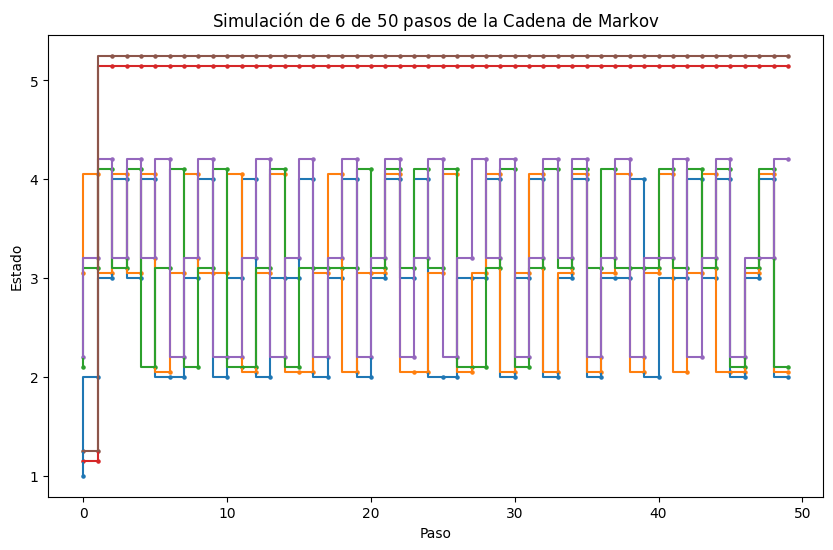

In [127]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 24
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1=np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples=6
n_steps=50

trayectorias=simular_trayectorias_effic(P,pi_sup_1,n_samples,n_steps)

plt.figure(figsize=(10, 6))
for i in range(n_samples):
  plt.step(range(n_steps), trayectorias[i, :]+i/20)
  plt.scatter(range(n_steps), trayectorias[i, :]+i/20, s=5)
plt.xlabel("Paso")
plt.ylabel("Estado")
plt.title("Simulación de $6$ de $50$ pasos de la Cadena de Markov")
plt.show()

---

## **3. Distribución marginal de una MC**

Defino una función que permita obtener la distribución marginal de una MC en un instante dado.

In [90]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Calcular la distribución marginal de una MC en cierto instante.

  INPUT:
    P (numpy.ndarry (m,m)): Matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): Distribución inicial de la MC.
    n (int): Paso en el que se quiere calcular la distribución marginal.

  OUTPUT:
    marginal (numpy.ndarry (m,)): distribución marginal en el instante n (es decir, según la notación de la asignatura pi^{(n)}).
  """
  marginal=pi_sup_1@np.linalg.matrix_power(P,n-1)
  return marginal

Utilizo la función anterior para visualizar empíricamente que la distribución marginal de la MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes.

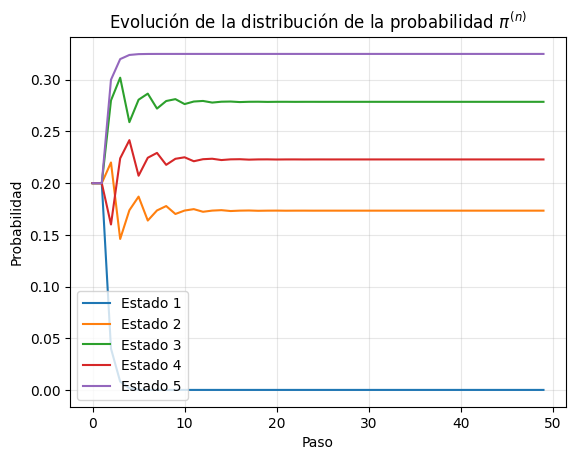

In [91]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 61
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1=np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n=50

evol_marginales=pi_sup_1
for i in range(49):
  evol_marginales=np.vstack((evol_marginales,obtener_marginal(P,pi_sup_1,i+1)))

plt.plot(evol_marginales,label=("Estado 1","Estado 2","Estado 3","Estado 4","Estado 5"))
plt.legend()
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title(r"Evolución de la distribución de la probabilidad $\pi^{(n)}$")
plt.grid(True,alpha=0.3)
plt.show()

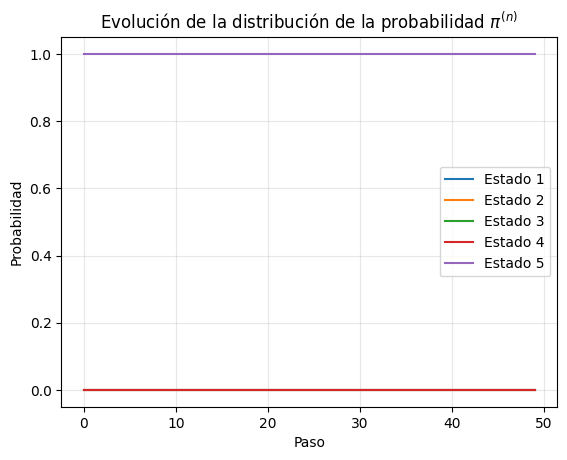

In [92]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 63
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1=np.array([0, 0, 0, 0, 1])
n=50

evol_marginales=pi_sup_1
for i in range(49):
  evol_marginales=np.vstack((evol_marginales,obtener_marginal(P,pi_sup_1,i+1)))

plt.plot(evol_marginales,label=("Estado 1","Estado 2","Estado 3","Estado 4","Estado 5"))
plt.legend()
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title(r"Evolución de la distribución de la probabilidad $\pi^{(n)}$")
plt.grid(True, alpha=0.3)
plt.show()


---

## **4. Diagrama de transición de estados**

Defino una función para dibujar el diagrama de transición de estados de una MC, una de las formas más habituales de visualizar una MC.

In [93]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  #Uso DiGraph (Directed Graph)
  G=nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j]>0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  pos=nx.circular_layout(G)

  plt.figure(figsize=(8, 6))

  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  edge_labels=nx.get_edge_attributes(G, 'weight')

  formatted_edge_labels={k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("Diagrama de transición de estados (con pesos)")
  plt.show()

Uso la función anterior para dibujar el diagrama de transición de estados de la MC.

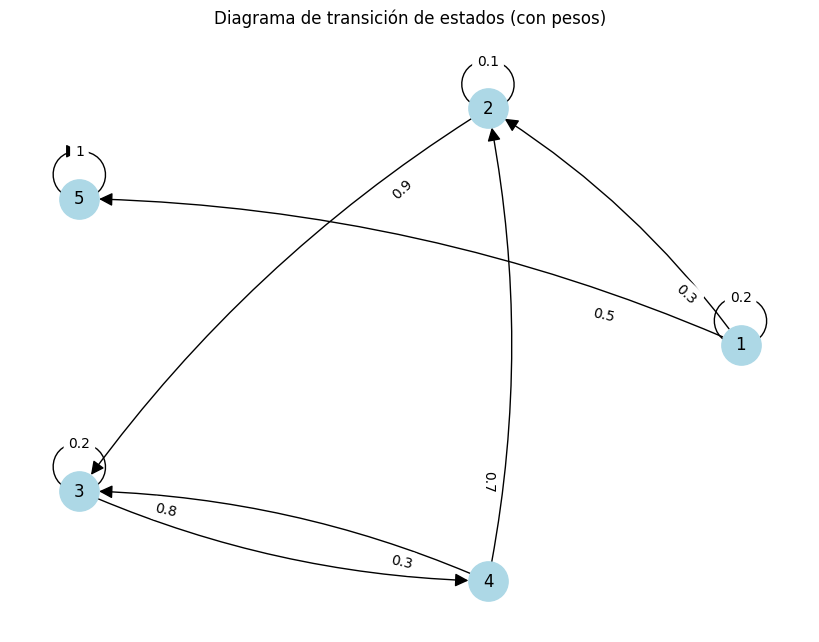

In [94]:
#RÉPLICA (APROXIMADA) DE LA DIAPOSITIVA 27
P=np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
states=range(1,6)
dibujar_diagrama_transicion(P,states)

---

## **5. Teorema de convergencia de MCs**
En esta sección se ilustran tres ideas relacionadas con el teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.

Empiezo por definir una función que permita visualizar la evolución de la distribución marginal de una MC. Este tipo de gráfica ya la había obtenido en la sección 4, cuando se reprodujeron las diapositivas 61 y 63. No obstante, aquí se encapsula en una función y se hace de manera más eficiente que allí:

In [95]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Visualizar la evolución de la distribución marginal para una MC.

  INPUT:
    P (numpy.ndarry (m,m)): Matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): Distribución inicial de la MC.
    n_steps (int): Número de pasos en los que se quiere calcular la distribución marginal.

  OUTPUT:
    No devuelve nada por "return", simplemente realiza un gráfico.
  """

  #Por exigencias del ejercicio, no hago uso la función "obtener_marginal" que había definido. Simplemente obtengo las marginales una a una a partir de la anterior multiplicando por P.
  m=np.shape(P)[1]
  evol_marginales=np.zeros((m,n_steps))
  evol_marginales[:,0]=pi_sup_1
  for i in range(1,n_steps):
    evol_marginales[:,i]=evol_marginales[:,i-1]@P

  plt.plot(np.transpose(evol_marginales))
  plt.xlabel("Paso")
  plt.ylabel("Probabilidad")
  plt.title(r"Evolución de la distribución de la probabilidad $\pi^{(n)}$")
  plt.grid(True, alpha=0.3)
  plt.show()

Considero la siguiente matriz de transición:

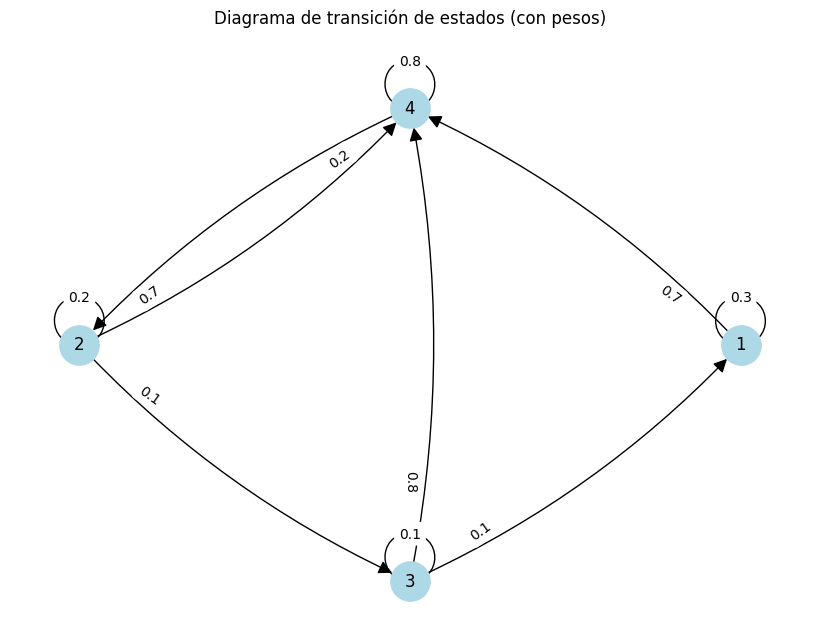

In [96]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Se de la matriz de transición de una MC unicadenal (de hecho irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. En consecuencia, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros  $50$  pasos de la marginal (también se imprime por pantalla la marginal en el paso $50$).

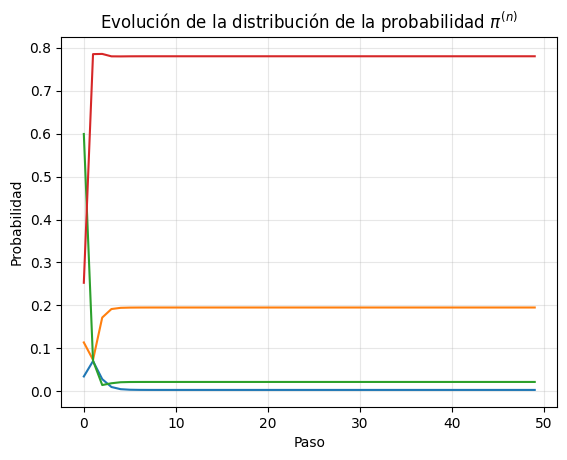

[0.00309598 0.19504644 0.02167183 0.78018576]


In [97]:
P=np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

pi_sup_1=np.random.rand(4)
pi_sup_1=pi_sup_1/sum(pi_sup_1)

visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

Se sabe que si $P$ es la matriz de transición de una MC irreducible y aperiódica, la sucesión de matrices $\{P^n\}_n$ converge a una matriz en la que todas las filas son iguales (que coincide con la única distribución estacionaria).

Se visualizan varios términos de esta sucesión para comprobar empíricamente que esto sucede mediante la representación en mapa de calor de las matrices. Para $P$ esta visualización es:

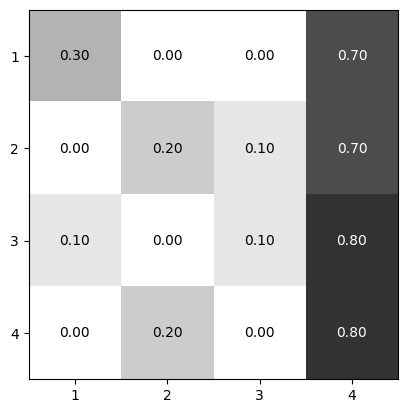

In [98]:
P=np.array([[0.3,0,0,0.7],
            [0,0.2,0.1,0.7],
            [0.1,0,0.1,0.8],
            [0,0.2,0,0.8]])

plt.imshow(P,cmap="binary",vmin=0,vmax=1)

m=P.shape[0]
for i in range(m):
  for j in range(m):
    value=P[i,j]
    text_color="white" if value>0.5 else "black"
    plt.text(j,i,f"{value:.2f}",ha="center",va="center",color=text_color,fontsize=10)

plt.xticks(np.arange(P.shape[0]),labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]),labels=1+np.arange(P.shape[0]))

plt.show()

En la siguiente celda se ve la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuve empíricamente dos celdas más arriba, cuando se estudió dónde parecía estabilizarse la marginal de la MC en el paso $50$. (En $(0.00309598, 0.19504644, 0.02167183, 0.78018576)$).

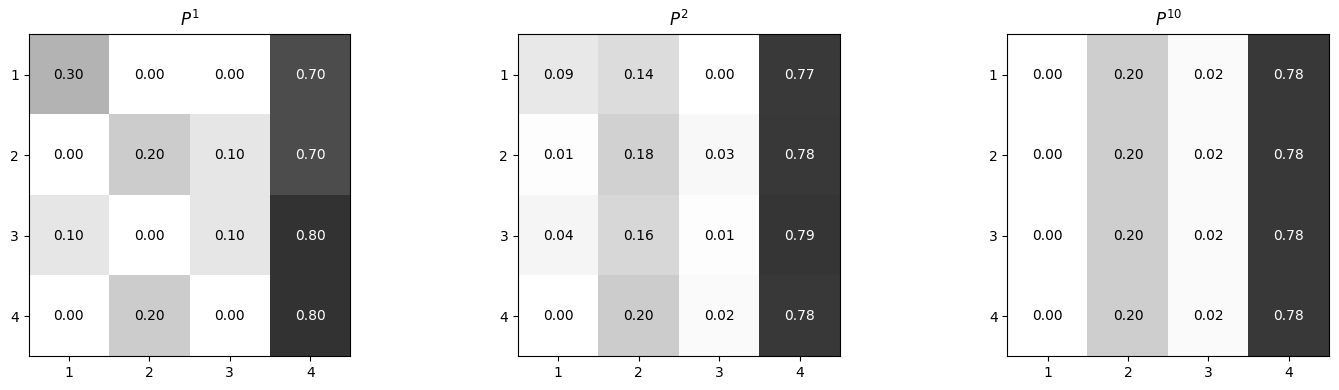

In [99]:
fig, axes=plt.subplots(1,3,figsize=(15,4))
steps_to_show=[1,2,10]

for ax, n in zip(axes, steps_to_show):
  Pn = np.linalg.matrix_power(P,n)

  im=ax.imshow(Pn,cmap='binary',vmin=0,vmax=1)
  ax.set_title(f"$P^{{{n}}}$")
  ax.set_xticks(np.arange(P.shape[0]),labels=1+np.arange(P.shape[0]))
  ax.set_yticks(np.arange(P.shape[0]),labels=1+np.arange(P.shape[0]))
  for i in range(Pn.shape[0]):
    for j in range(Pn.shape[1]):
      value=Pn[i,j]
      text_color="white" if value>0.5 else "black"
      ax.text(j,i,f"{value:.2f}",ha="center",va="center",color=text_color,fontsize=10)

plt.tight_layout()
plt.show()

Voy a abordar ahora el segundo punto de esta sección. En primer lugar, se puede comprobar que la siguente matriz $P$ se corresponde con la matriz de transición de una MC periódica de periodo $2$.

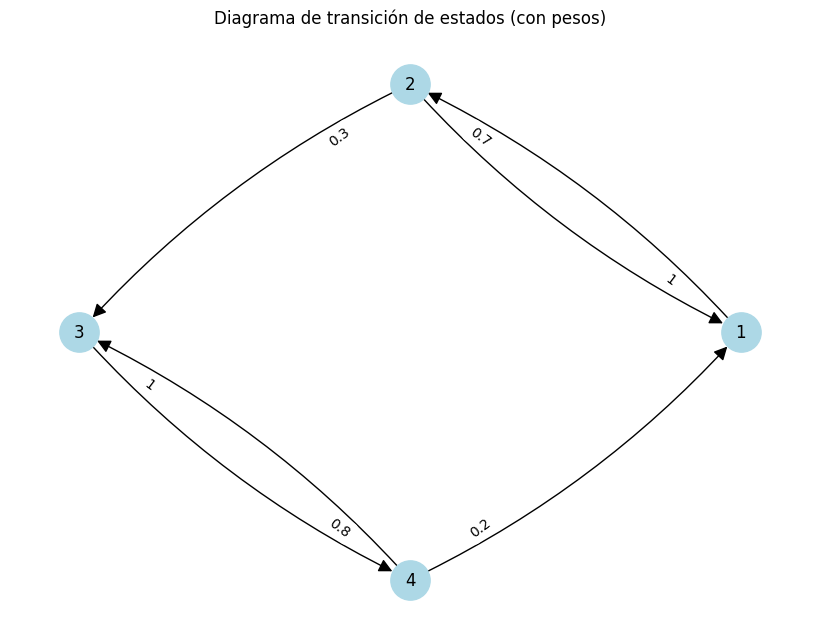

In [100]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes tres celdas se usa la función `visualizar_evolucion_marginal` para ver la evolución de la marginal para tres distribuciones iniciales diferentes. En cada celda, también se imprime por pantalla la marginal en el paso $50$:

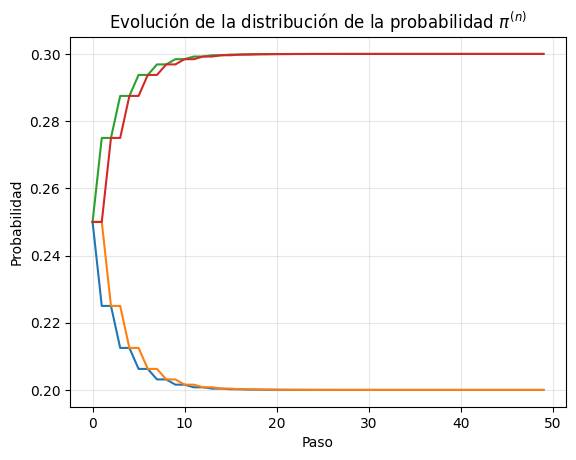

[0.2 0.2 0.3 0.3]


In [101]:
pi_sup_1=np.array([0.25,0.25,0.25,0.25])
visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

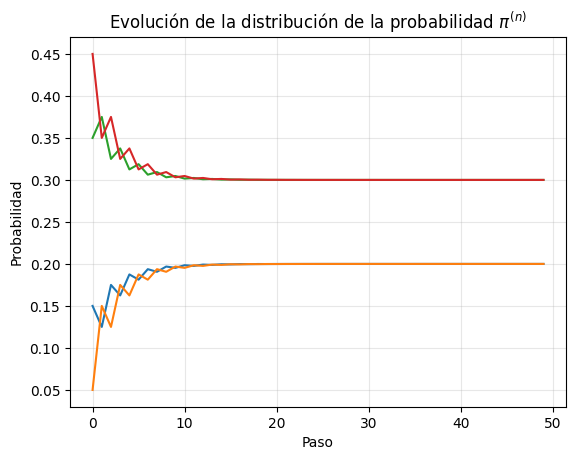

[0.2 0.2 0.3 0.3]


In [102]:
pi_sup_1=np.array([0.15,0.05,0.35,0.45])
visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

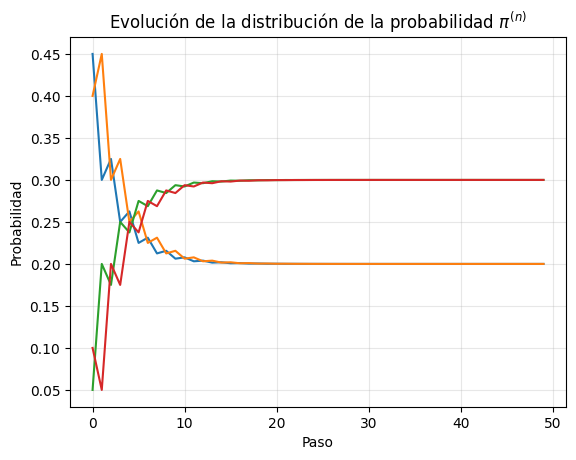

[0.20000001 0.20000001 0.29999999 0.29999999]


In [103]:
pi_sup_1=np.array([0.45,0.40,0.05,0.10])
visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

En los tres casos, parece producirse convergencia de la marginal a la distribución $(0.2, 0.2, 0.3, 0.3)$. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales.

Para mostrar que esto no contradice el resultado enunciado en la diapositiva 96, propongo en las siguientes dos celdas distribuciones iniciales para la que no hay convergencia y las visualizo:

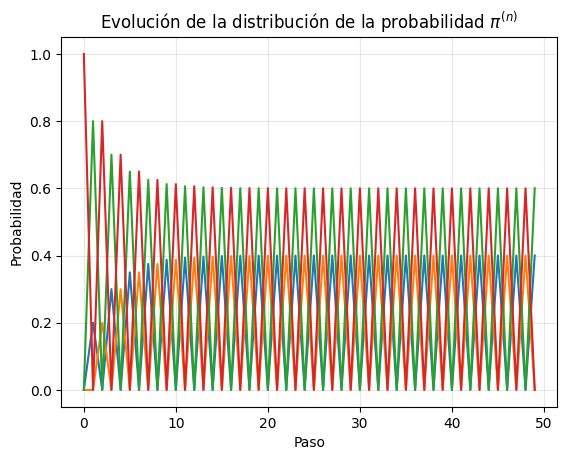

[0.39999999 0.         0.60000001 0.        ]


In [104]:
pi_sup_1=np.array([0.,0.,0.,1.])
visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

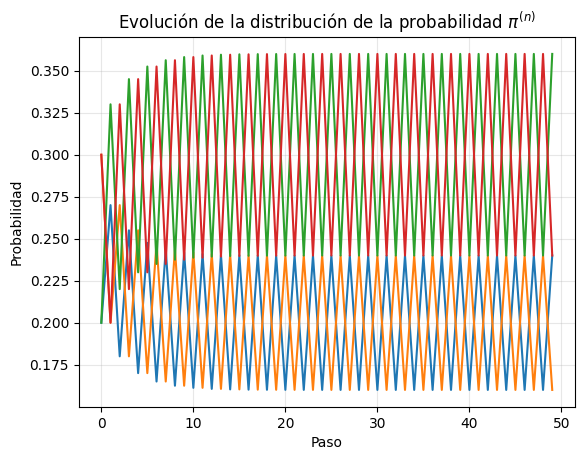

[0.24 0.16 0.36 0.24]


In [105]:
pi_sup_1=np.array([0.2,0.3,0.2,0.3])
visualizar_evolucion_marginal(P,pi_sup_1,50)
print(obtener_marginal(P,pi_sup_1,50))

Voy a mirar el tercer y último punto de esta sección. En la siguiente celda, voy a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.

In [106]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):
  """
  Obtener las proporciones empíricas de cada uno de los estados y en cada uno de los pasos, cuando se simula una cantidad dada de trayectorias.

  INPUT:
    n_samples(int): número de trayectorias a simular.
    n_steps (int): paso hasta el que se quieren calcular las proporciones.
    P (numpy.ndarry (m,m)): matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): distribución inicial de la MC.

  OUTPUT:
    props (numpy.ndarry (m,n_steps)): Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps.
  """

  m=np.shape(P)[1]
  trayectorias=simular_trayectorias_effic(P,pi_sup_1,n_samples,n_steps)

  estado=np.arange(1,m+1)
  estado=estado.reshape(-1,1,1)
  is_equal_bool=estado==trayectorias

  props=np.mean(is_equal_bool,axis=1)

  return props

Utilizo la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Hago la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección:

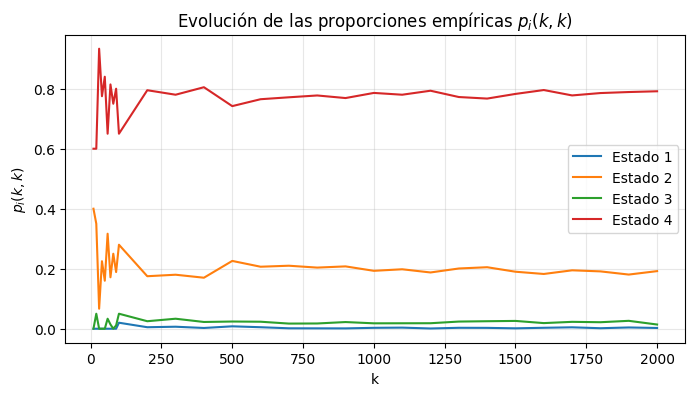

[0.0025 0.192  0.014  0.7915]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [107]:
# Definimos la MC (nada que completar aquí)
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25,0.25,0.25,0.25])
m=np.shape(P)[1]

grid=np.concatenate((np.arange(10,101,10),np.arange(200,2001,100)))

props_plot=np.zeros((m,len(grid)))
for j in range(len(grid)):
  props_plot[:,j]=proporciones_empiricas_hasta_cierto_paso(grid[j],grid[j],P,pi_sup_1)[:,-1]

plt.figure(figsize=(8,4))
for i in range(m):
  plt.plot(grid,props_plot[i,:],label=f"Estado {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolución de las proporciones empíricas $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(props_plot[:,-1])
print(obtener_marginal(P,pi_sup_1,50))

---

## **6. Teorema ergódico**

En esta sección voy a verificar empíricamente el teorema ergódico para algunas MCs.

El teorema ergódico se enuncia para una función $f:S\to\mathbb{R}$ arbitraria. Aquí voy a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaré calculando lo que se denotaba por $q_i(n)$ en la diapositiva 106. Cabe destacar que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:

$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.

Comienzo definiendo una función que, dada una MC (`P` y `pi_sup_1`) y una cantidad de pasos `n_steps`, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Dichos valores los devolverá en un array con shape (m, n_steps).

In [108]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Calcular la frecuencia empírica de visitas a cada uno de los estados para una trayectoria de una MC hasta cierto paso.

  INPUT:
    n_steps (int): paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps.
    P (numpy.ndarry (m,m)): matriz de transición de la MC.
    pi_sup_1 (numpy.ndarry (m,)): distribución inicial de la MC.

  OUTPUT:
    frecuencias_hasta_cierto_paso (numpy.ndarry (m,n_steps)): frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps.
  """

  m=np.shape(P)[1]
  trayectorias=simular_trayectorias_effic(P,pi_sup_1,1,n_steps)

  estado=np.arange(1,m+1)
  estado=estado.reshape(-1,1)
  is_equal_bool=estado==trayectorias

  recuentos_hasta_cierto_paso=np.cumsum(is_equal_bool,axis=1)

  pasos=np.arange(1,n_steps+1)
  frecuencias_hasta_cierto_paso=recuentos_hasta_cierto_paso/pasos

  return frecuencias_hasta_cierto_paso

Utilizo esta función para visualizar el teorema ergódico en dos MCs que unicadenales, y por tanto en las hipótesis del teorema ergódico. Primero miraré una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomo la que he usado al principio de la sección anterior:

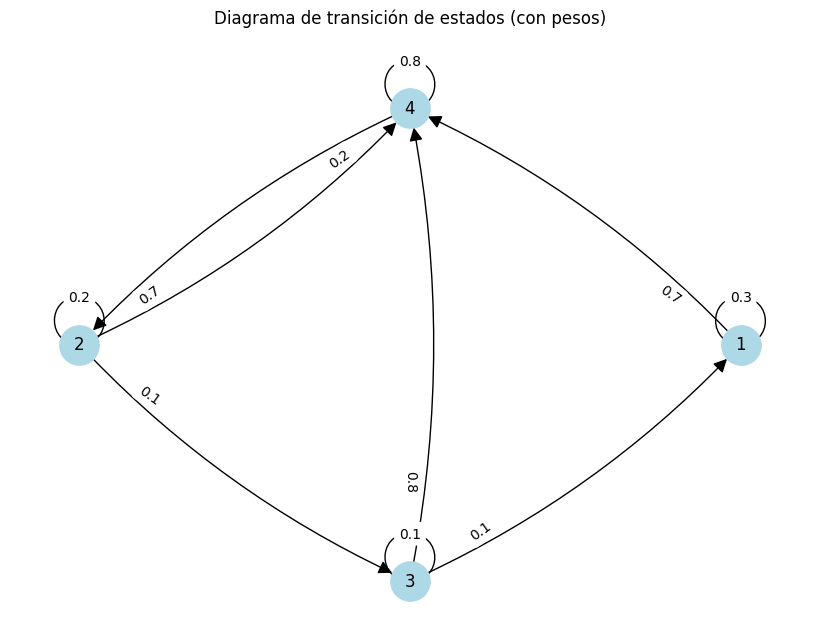

In [109]:
P=np.array([[0.3,0,0,0.7],
            [0,0.2,0.1,0.7],
            [0.1,0,0.1,0.8],
            [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P,[1,2,3,4])

La distribución estacionaria de esta MC parecía estar entorno a
$$(0.003, \; 0.195, \; 0.022, \; 0.780)$$
puesto que la marginal se estabilizaba en esos valores. Se va a poner de manifiesto que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

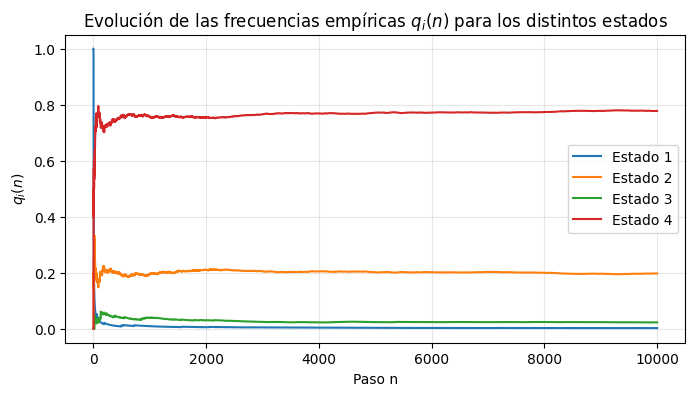

[0.0023 0.1972 0.0227 0.7778]


In [110]:
P=np.array([[0.3,0,0,0.7],
            [0,0.2,0.1,0.7],
            [0.1,0,0.1,0.8],
            [0,0.2,0,0.8]])
pi_sup_1=np.array([0.25,0.25,0.25,0.25])

n_steps=10000
m=P.shape[0]

frecs=frecuencia_empirica_hasta_cierto_paso(n_steps,P,pi_sup_1)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1,n_steps+1),frecs[i,:],label=f"Estado {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolución de las frecuencias empíricas $q_i(n)$ para los distintos estados")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Por último, voy a considerar la MC periódica de la sección anterior:

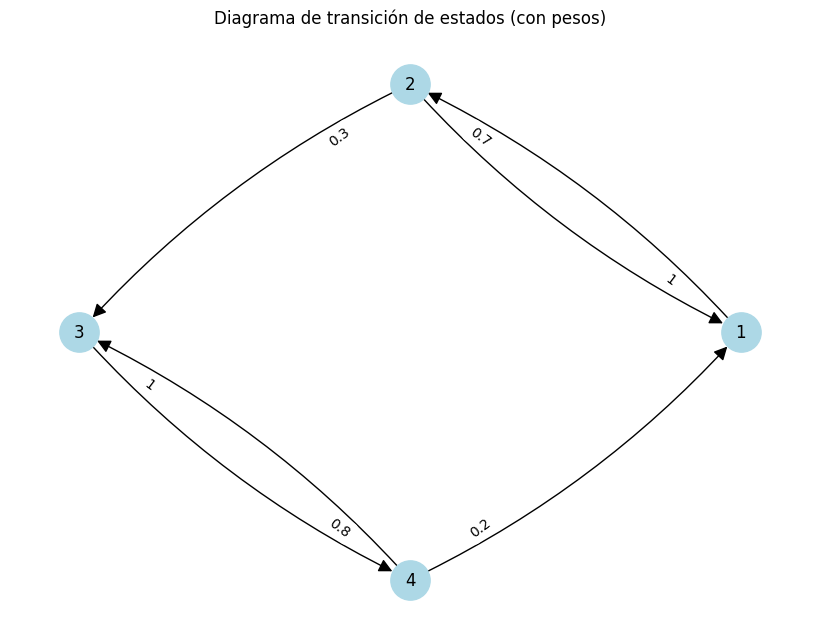

In [111]:
P=np.array([[0.0,1.0,0.0,0.0],
            [0.7,0.0,0.3,0.0],
            [0.0,0.0,0.0,1.0],
            [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P,np.arange(1,P.shape[0]+1))

Pruebo empíricamente que, con las distribuciones iniciales `pi_sup_1` para las que vi en la sección anterior que la distribución marginal no converge, el teorema ergódico se verifica y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, cabe reseñar que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MC's).

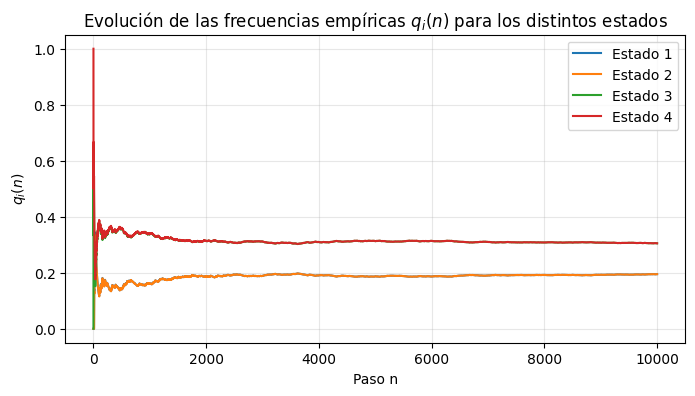

[0.195  0.1949 0.305  0.3051]


In [112]:
P=np.array([[0.0,1.0,0.0,0.0],
            [0.7,0.0,0.3,0.0],
            [0.0,0.0,0.0,1.0],
            [0.2,0.0,0.8,0.0]])
pi_sup_1=np.array([0.,0.,0.,1.])

n_steps=10000
m=P.shape[0]

frecs=frecuencia_empirica_hasta_cierto_paso(n_steps,P,pi_sup_1)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1,n_steps+1),frecs[i,:],label=f"Estado {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolución de las frecuencias empíricas $q_i(n)$ para los distintos estados")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

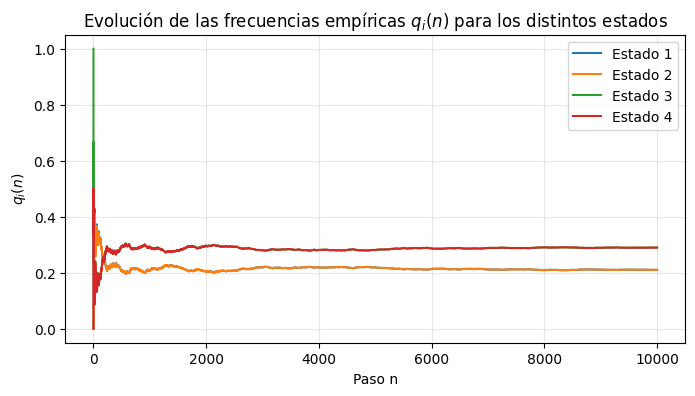

[0.2103 0.2103 0.2897 0.2897]


In [113]:
P=np.array([[0.0,1.0,0.0,0.0],
            [0.7,0.0,0.3,0.0],
            [0.0,0.0,0.0,1.0],
            [0.2,0.0,0.8,0.0]])
pi_sup_1=np.array([0.2,0.3,0.2,0.3])

n_steps=10000
m=P.shape[0]

frecs=frecuencia_empirica_hasta_cierto_paso(n_steps,P,pi_sup_1)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1,n_steps+1),frecs[i,:],label=f"Estado {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolución de las frecuencias empíricas $q_i(n)$ para los distintos estados")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Lo que converge al valor esperado. En efecto, en la sección anterior se vio que la única distribución estacionaria de esta MC venía dada por: $(0.2, 0.2, 0.3, 0.3)$.